## APS02 - **Classificação**

## 1. Contextualização do problema

#### *Previsao de renda anual* 

O objetivo do projeto é desenvolver e avaliar modelos de classificação binária que consigam prever se um indivíduo ganhar mais de 50K por ano ou não. Terei como base caracteristicas demográficas, educacionais e ocupacionais presentes no Adult Census Income Dataset.

No enunciado do problema, recebemos como dicas que as features com maior poder discriminativo esperados são: education-num, capital-loss, hours-per-week, age, marital-status, occupation e relationship. Dada a ajuda, analisarei cada uma delas e verei seus impactos e, respectivas relevâncias.

### Qual a relevância disso?
- *Políticas publicas*: Identificar grupos populacionais com potencial de renda elevada.
- *Análise de desigualdade social*: Compreender fatores que determinam diferenças salariais.
- *Pesquisa economica*: Estudo sobre mobilidade social e fatores de sucesso econômico. 

### Características do Dataset:
| Aspecto | Detalhe |
|--------|----------|
| **Total de instâncias** | 48,842 (treino: 32,561 / teste: 16,281) |
| **Total de atributos** | 14 |
| **Tipo de variáveis** | Mistas (contínuas e categóricas) |
| **Classe positiva (>50K)** | ~23.93% (DESBALANCEADA) |
| **Classe negativa (<=50K)** | ~76.07% (DESBALANCEADA) |
| **Valores faltantes** | Marcados com "?" |

### Compreender as features com maior poder discriminativo:
1. *education-num*: Número de anos de educação (escalar)
2. *capital-gain*: Ganhos de capital (contínua)
3. *capital-loss*: Perda de capital (contínua)
4. *hours-per-week*: Horas trabalhadas por semana (contínua)
5. *age*: Idade do indivíduo (contínua)
6. *marital-status*: Estado civil (categórica)
7. *occupation*: Ocupação profissional (categórica)
8. *relationship*: Relacionamento familiar (categórica)

### Desafios identificados:
- **Desbalanceamento de classes**: Proporção de 76% vs 24%
- **Valores faltantes**: Presença de "?"
- **Variáveis categóricas**: Requerem encoding
- **Escalas diferentes**: Features com escalas distintas
- **Outliers potenciais**: Capital-gain e capital-loss têm distribuição assimétrica

## 2. Setup e importações:
Vou importar tudo que eu vá usar para o projeto.

In [1]:
# Importações básicas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Pré-processamento
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold, GridSearchCV

# Balanceamento
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, auc, precision_recall_curve, roc_curve,
    classification_report, confusion_matrix
)

# Configuração de plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Todas as bibliotecas importadas com sucesso!")

✓ Todas as bibliotecas importadas com sucesso!


## 3. Carregamento e exploração dos dados

In [3]:
# Carregamento dos dados de treino e teste

column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Carregar dados
df_train = pd.read_csv('adult/adult.data', 
                        names=column_names, 
                        sep=', ',  # Separador específico do dataset
                        engine='python',
                        na_values=['?'])

df_test = pd.read_csv('adult/adult.test', 
                       names=column_names, 
                       sep=', ',  # Separador específico do dataset
                       engine='python',
                       na_values=['?'],
                       skiprows=1)  # Pular cabeçalho

print(f"Data de treino: {df_train.shape}")
print(f"Data de teste: {df_test.shape}")
print(f"\nTotal combinado: {df_train.shape[0] + df_test.shape[0]} registros")

Data de treino: (32561, 15)
Data de teste: (16281, 15)

Total combinado: 48842 registros


In [4]:
# Combinando treino e teste para pré-processamento
df = pd.concat([df_train, df_test], ignore_index=True)

print("="*80)
print("VISUALIZAÇÃO INICIAL DOS DADOS")
print("="*80)
print(f"\nForma: {df.shape}")
print(f"\nPrimeiras 3 linhas:")
print(df.head(3))

# Informações sobre tipos de dados
print(f"\n\nTipos de Dados:")
print(df.dtypes)

# Valores faltantes
print(f"\n\nValores Faltantes:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"Percentual: {(missing/len(df)*100)[missing > 0].round(2)}%")

VISUALIZAÇÃO INICIAL DOS DADOS

Forma: (48842, 15)

Primeiras 3 linhas:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   

       marital-status         occupation   relationship   race   sex  \
0       Never-married       Adm-clerical  Not-in-family  White  Male   
1  Married-civ-spouse    Exec-managerial        Husband  White  Male   
2            Divorced  Handlers-cleaners  Not-in-family  White  Male   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0              13  United-States  <=50K  
2             0             0              40  United-States  <=50K  


Tipos de Dados:
age               int64
workclass           str
fnlwgt            int64
education           

ANÁLISE DA VARIÁVEL-ALVO (income)

Distribuição:
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

Percentuais:
income
<=50K     50.61
<=50K.    25.46
>50K      16.05
>50K.      7.87
Name: count, dtype: float64


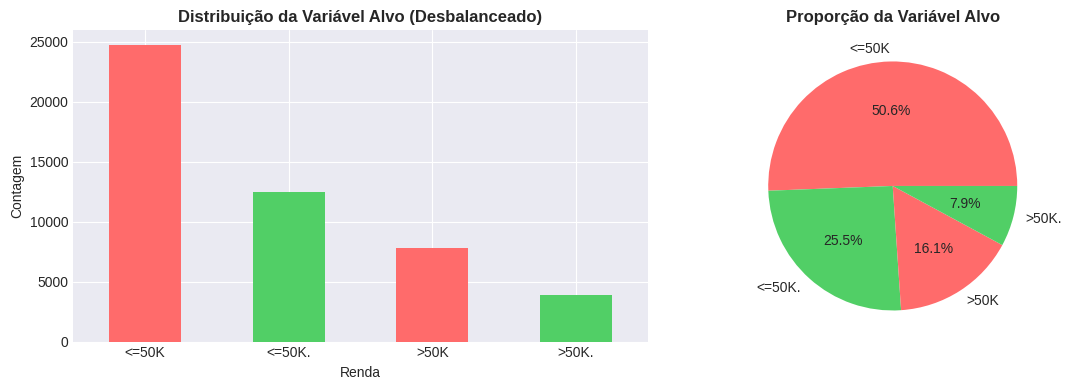

In [7]:
# Análise da variável alvo
print("="*80)
print("ANÁLISE DA VARIÁVEL-ALVO (income)")
print("="*80)

# Limpar espaços em branco na coluna de renda
df['income'] = df['income'].str.strip()

# Distribuição
print(f"\nDistribuição:")
target_counts = df['income'].value_counts()
print(target_counts)
print(f"\nPercentuais:")
print((target_counts / len(df) * 100).round(2))

# Visualizar desbalanceamento
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
target_counts.plot(kind='bar', ax=ax[0], color=['#ff6b6b', '#51cf66'])
ax[0].set_title('Distribuição da Variável Alvo (Desbalanceado)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Contagem')
ax[0].set_xlabel('Renda')
ax[0].tick_params(axis='x', rotation=0)

# Gráfico de pizza
colors = ['#ff6b6b', '#51cf66']
ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=colors)
ax[1].set_title('Proporção da Variável Alvo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Podemos observar que temos um **problema identificado**: 
Classes desbalanceadas!

ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS

Variáveis numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
            age      fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.00    48842.00       48842.00      48842.00       48842.0   
mean      38.64   189664.13          10.08       1079.07          87.5   
std       13.71   105604.03           2.57       7452.02         403.0   
min       17.00    12285.00           1.00          0.00           0.0   
25%       28.00   117550.50           9.00          0.00           0.0   
50%       37.00   178144.50          10.00          0.00           0.0   
75%       48.00   237642.00          12.00          0.00           0.0   
max       90.00  1490400.00          16.00      99999.00        4356.0   

       hours-per-week  
count        48842.00  
mean            40.42  
std             12.39  
min              1.00  
25%             40.00  
50%             40.00  
75%             45.00

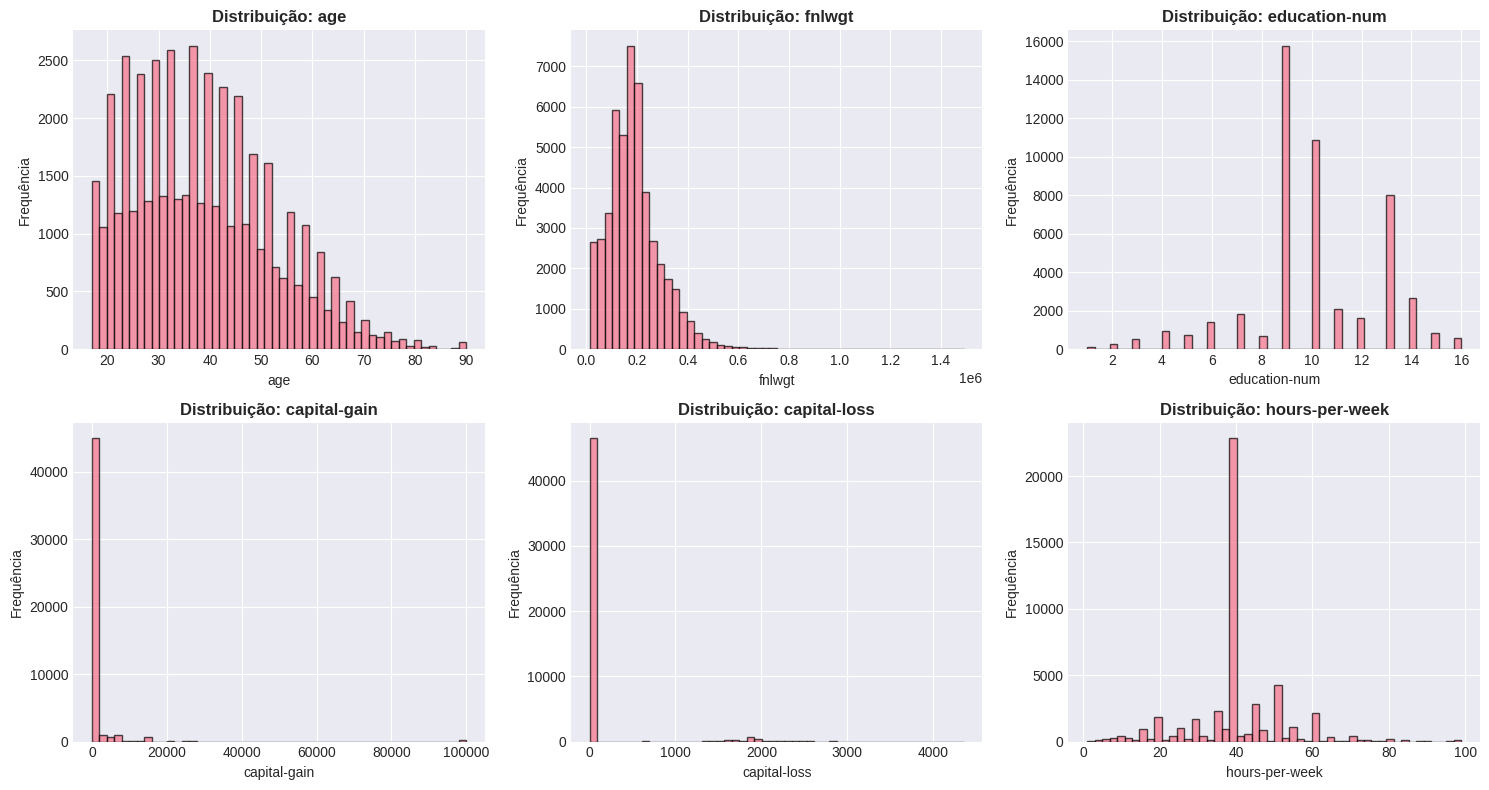

In [9]:
# Análise das variáveis numéricas
print("="*80)
print("ESTATÍSTICAS DAS VARIÁVEIS NUMÉRICAS")
print("="*80)

numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nVariáveis numéricas: {list(numeric_cols)}")
print(df[numeric_cols].describe().round(2))

# Visualizar distribuições
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribuição: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequência')

plt.tight_layout()
plt.show()


O que conseguimos extrair disso?
- 'age': Distribuição aproximadamente normal, range 17-90
- 'education-num': Distribuição discreta, valores de 1 a 16
- 'capital-gain' e 'capital-loss': Altamente assimétricos (muitos zeros)
- 'hours-per-week': Concentrado em 40 horas

In [10]:
# Análise das variáveis categóricas
print("="*80)
print("ANÁLISE DAS VARIÁVEIS CATEGÓRICAS")
print("="*80)

categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('income')  # Remove alvo

print(f"\nVariáveis categóricas: {categorical_cols}")

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(f"  Valores únicos: {df[col].nunique()}")
    print(f"  Valores: {df[col].value_counts().index.tolist()}")
    print(f"  Distribuição:")
    print(df[col].value_counts())
    print()

ANÁLISE DAS VARIÁVEIS CATEGÓRICAS

Variáveis categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

WORKCLASS:
  Valores únicos: 8
  Valores: ['Private', 'Self-emp-not-inc', 'Local-gov', 'State-gov', 'Self-emp-inc', 'Federal-gov', 'Without-pay', 'Never-worked']
  Distribuição:
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


EDUCATION:
  Valores únicos: 16
  Valores: ['HS-grad', 'Some-college', 'Bachelors', 'Masters', 'Assoc-voc', '11th', 'Assoc-acdm', '10th', '7th-8th', 'Prof-school', '9th', '12th', 'Doctorate', '5th-6th', '1st-4th', 'Preschool']
  Distribuição:
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10

In [11]:
# Relação das features com alvo (as dicas do problema)
print("="*80)
print("FEATURES COM MAIOR PODER DISCRIMINATIVO (dicas do problema)")
print("="*80)

target_features = ['education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 
                   'age', 'marital-status', 'occupation', 'relationship']

# Para features numéricas: comparar médias
print(f"\nComparação de MÉDIAS entre classes:")
print(f"{'Feature':<20} {'<=50K':<15} {'>50K':<15} {'Diferença':<15}")
print("-" * 65)

for col in ['education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'age']:
    if col in numeric_cols:
        mean_neg = df[df['income'] == '<=50K'][col].mean()
        mean_pos = df[df['income'] == '>50K'][col].mean()
        diff = mean_pos - mean_neg
        print(f"{col:<20} {mean_neg:<15.2f} {mean_pos:<15.2f} {diff:<15.2f}")

# Para features categóricas: mostrar distribuição
print(f"\n\nDistribuição de CATEGÓRICAS por renda:")
for col in ['marital-status', 'occupation', 'relationship']:
    print(f"\n{col.upper()}:")
    crosstab = pd.crosstab(df[col], df['income'], margins=True)
    print(crosstab)
    print()

FEATURES COM MAIOR PODER DISCRIMINATIVO (dicas do problema)

Comparação de MÉDIAS entre classes:
Feature              <=50K           >50K            Diferença      
-----------------------------------------------------------------
education-num        9.60            11.61           2.02           
capital-gain         148.75          4006.14         3857.39        
capital-loss         53.14           195.00          141.86         
hours-per-week       38.84           45.47           6.63           
age                  36.78           44.25           7.47           


Distribuição de CATEGÓRICAS por renda:

MARITAL-STATUS:
income                 <=50K  <=50K.  >50K  >50K.    All
marital-status                                          
Divorced                3980    1982   463    208   6633
Married-AF-spouse         13      10    10      4     37
Married-civ-spouse      8284    4111  6692   3292  22379
Married-spouse-absent    384     186    34     24    628
Never-married          

### Observações finais sobre a exploração dos dados
Depois de ter feito tudo isso a gente consegue observar padrões, como:
#### Alta renda (>50K) = Tipicamente:
- educação (13+ anos)
- casado
- trabalhando 45+ horas por semana 
- Idade 40-50 anos
- Pode ter capital investiments
#### Baixa renda (<= 50K) = Tipicamente:
- Menos educação (10 anos)
- Solteiro ou divorciado
- 35-40 horas por semana
- jovem 20 - 30 anos
- Sem atividade financeira